# 실습 15: 언제부터 그랬는지 보기
- 상황: 이상한 줄은 찾았는데 그게 언제 나온 건지 모른다
- 목표: 시각을 되살려 흐름으로 감시하고, 조기 경보 목록으로 마감한다

## Step 0. 앞 실습까지 재현하기

In [1]:
import pandas as pd
from sklearn.ensemble import IsolationForest

df = pd.read_csv("../../day02/lab06_clean-dataset/results/secom_clean.csv")

sensor_cols = [c for c in df.columns if c.startswith("sensor_")]
df[sensor_cols] = df[sensor_cols].fillna(df[sensor_cols].median())

X = df[sensor_cols]

탐지기 = IsolationForest(contamination=0.05, random_state=42)
지목 = 탐지기.fit_predict(X)

df["불량여부"] = (df["result"] == "불량").astype(int)
df["이상탐지"] = (지목 == -1)

print("전체 행 수:", len(df))
print("이상탐지 건수:", df["이상탐지"].sum())
print("그중 불량 건수:", (df["이상탐지"] & (df["불량여부"] == 1)).sum())


전체 행 수: 1567
이상탐지 건수: 79
그중 불량 건수: 15


## Step 1. 오늘 쓸 말 정리하기

### 용어 풀이 - 흐름으로 보는 말

| 수업에서 쓰는 말 | 정식 이름 | 뜻 |
|---|---|---|
| 시계열 | time series | 시간 순서가 있는 기록. 앞뒤가 이어져 있어서 순서를 바꾸면 뜻이 달라진다 |
| 이동평균 | 이동평균 (moving average) | 최근 몇 개의 평균. 들쭉날쭉한 걸 눌러서 흐름만 남긴다 |
| 관리도 | 관리도 (control chart) | 평소 범위를 선으로 그려두고 넘는 순간을 잡는 그림 |
| 관리 한계선 | 관리상한 UCL / 관리하한 LCL | 그 선. 흔히 평균에서 표준편차의 세 배만큼 위아래로 긋는다 |
| 이탈 | 관리 이탈 (out of control) | 관리 한계선을 넘은 것 |
| 관리도로 공정을 지켜보는 일 | 통계적 공정관리 (SPC) | 현장에서 백 년 가까이 써온 방법. 면접에서 이 이름으로 묻는다 |

## Step 2. 떨어져 나간 시각 다시 붙이기

In [2]:
import pandas as pd

# ① 파일을 불러오는 것 - 첫날부터 계속 쓴 것
원본 = pd.read_csv("../../data/04_secom.csv")
df = 원본.copy()

# ② 글자로 된 시각을 날짜로 바꿔주는 것
# ③ 표기가 섞여 있어도 알아서 읽으라는 뜻. 안 넣으면 오류가 난다
df["측정시각"] = pd.to_datetime(원본["measured_at"], format="mixed")

# 붙이기 전에 확인 - 두 파일의 행 순서가 같아야 붙일 수 있다
# ④ 전부 참일 때만 참이 되는 것
print("정제본 행 수:", len(df), "/ 원본 행 수:", len(원본))
print("답이 전부 같은가:", (df["result"].values == 원본["result"].values).all())

# ⑤ 그 열 기준으로 줄을 세우는 것
# ⑥ 옛 번호를 버리라는 뜻
df = df.sort_values("측정시각").reset_index(drop=True)

print("기간:", df["측정시각"].min(), "~", df["측정시각"].max())

정제본 행 수: 1567 / 원본 행 수: 1567
답이 전부 같은가: True
기간: 2008-01-08 02:02:00 ~ 2008-12-10 18:47:00


### 문법 노트 - 시각 붙이고 줄 세우기

| 밑줄 | 넣은 것 | 하는 일 | 새로 배운 것인가 |
|---|---|---|---|
| ① | `read_csv` | 파일을 불러온다 | 첫날부터 계속 쓴 것 |
| ② | `to_datetime` | 글자로 된 시각을 날짜로 바꾼다 | 정제할 때 한 번 나왔다 |
| ③ | `format="mixed"` | 표기가 섞여 있어도 알아서 읽으라는 뜻 | 새로 배움 · 안 넣으면 오류 |
| ④ | `.all()` | 전부 참일 때만 참 | 새로 배움 |
| ⑤ | `sort_values` | 그 열 기준으로 줄을 세운다 | 새로 배움 |
| ⑥ | `drop` | 번호를 다시 매기고 옛 번호는 버린다 | 새로 배움 |

## Step 4. 월별로 보면

In [3]:
# Step 2에서 df를 원본으로 다시 만들었으므로 불량여부를 다시 만들어둔다
df["불량여부"] = (df["result"] == "불량").astype(int)

# 측정시각에서 연-월만 뽑아 월별로 묶는다
df["월"] = df["측정시각"].dt.to_period("M").astype(str)

월별표 = df.groupby("월").agg(
    전체건수=("불량여부", "size"),
    불량건수=("불량여부", "sum"),
).reset_index()
월별표["불량률(%)"] = round(월별표["불량건수"] / 월별표["전체건수"] * 100, 2)

print(월별표.to_string(index=False))

최고행 = 월별표.loc[월별표["불량률(%)"].idxmax()]
최저행 = 월별표.loc[월별표["불량률(%)"].idxmin()]
print(f"\n불량률이 가장 높은 달: {최고행['월']} ({최고행['불량률(%)']}%) / 가장 낮은 달: {최저행['월']} ({최저행['불량률(%)']}%)")


      월  전체건수  불량건수  불량률(%)
2008-01    51     3    5.88
2008-02    98     5    5.10
2008-03    50     1    2.00
2008-04    49     3    6.12
2008-05    62     7   11.29
2008-06    67     6    8.96
2008-07   114    16   14.04
2008-08   471    38    8.07
2008-09   413    17    4.12
2008-10   123     6    4.88
2008-11    35     2    5.71
2008-12    34     0    0.00

불량률이 가장 높은 달: 2008-07 (14.04%) / 가장 낮은 달: 2008-12 (0.0%)


## Step 5. 흐름 보고 관리선 긋기

In [4]:
# 볼 센서 하나를 고른다
센서 = "sensor_039"

# ⑦ 창문을 미끄러뜨리며 묶어주는 것
# ⑧ 몇 개씩 묶을지 정하는 자리
# ⑨ 묶은 것들의 평균을 내는 것
df["이동평균"] = df[센서].rolling(window=20).mean()

# 평소 범위를 정한다. 첫날에 한 그 방법이다
# ⑩ 값들이 평균에서 얼마나 벌어져 있는지 재는 것
평균 = df[센서].mean()
표준편차 = df[센서].std()

# ⑪ 평균에서 표준편차의 몇 배만큼 그을지
상한 = 평균 + 3 * 표준편차
하한 = 평균 - 3 * 표준편차

print(f"평균 {평균:.2f} / 표준편차 {표준편차:.2f}")
print(f"관리 상한 {상한:.2f} / 관리 하한 {하한:.2f}")

# ⑫ 위로 넘었거나 아래로 넘었거나 - 한쪽만 참이어도 참인 기호
df["이탈"] = (df[센서] > 상한) | (df[센서] < 하한)

# 불량 표시를 df 안에서 다시 만든다
df["불량여부"] = (df["result"] == "불량").astype(int)

print("이탈:", df["이탈"].sum(), "건 / 그중 불량", (df["이탈"] & (df["불량여부"] == 1)).sum(), "건")

평균 86.84 / 표준편차 0.45
관리 상한 88.18 / 관리 하한 85.50
이탈: 71 건 / 그중 불량 15 건


### 문법 노트 - 흐름과 관리선

선을 넘었는지 볼 때 두 조건을 묶는다.

    위로 넘었거나 아래로 넘었거나  ->  |

| 밑줄 | 넣은 것 | 하는 일 | 새로 배운 것인가 |
|---|---|---|---|
| ⑦ | `rolling` | 창문을 미끄러뜨리며 묶는다 | 새로 배움 |
| ⑧ | `window` | 몇 개씩 묶을지 정하는 자리 | 새로 배움 |
| ⑨ | `.mean()` | 묶은 것들의 평균 | 첫날부터 쓴 것 |
| ⑩ | `.std()` | 표준편차 - 평균에서 얼마나 벌어져 있나 | 첫날 관리선·지난주 흔들림에서 썼다 |
| ⑪ | `3` | 표준편차의 세 배로 선을 긋는다 | 첫날에 정한 그 배수 |
| ⑫ | `\|` | 한쪽이라도 참이면 참 | 앞 실습에서 배웠다 |

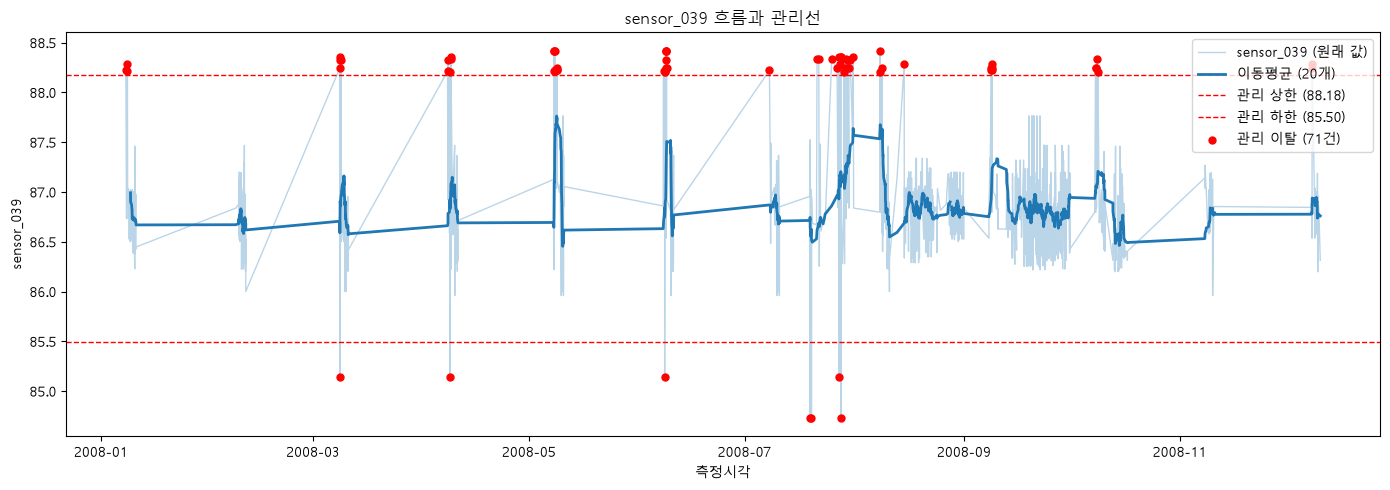

저장 완료: results/sensor_trend.png


In [5]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# 한글이 깨지지 않도록 윈도우 기본 한글 글꼴을 쓴다
mpl.rcParams["font.family"] = "Malgun Gothic"
mpl.rcParams["axes.unicode_minus"] = False

fig, ax = plt.subplots(figsize=(14, 5))

# 원래 값은 옅게
ax.plot(df["측정시각"], df[센서], color="tab:blue", alpha=0.3, linewidth=1, label=f"{센서} (원래 값)")

# 이동평균은 진하게
ax.plot(df["측정시각"], df["이동평균"], color="tab:blue", linewidth=2, label="이동평균 (20개)")

# 관리 상한/하한을 가로선으로
ax.axhline(상한, color="red", linestyle="--", linewidth=1, label=f"관리 상한 ({상한:.2f})")
ax.axhline(하한, color="red", linestyle="--", linewidth=1, label=f"관리 하한 ({하한:.2f})")

# 관리선을 넘은 지점만 눈에 띄게 표시
이탈행 = df[df["이탈"]]
ax.scatter(이탈행["측정시각"], 이탈행[센서], color="red", s=25, zorder=5,
           label=f"관리 이탈 ({len(이탈행)}건)")

ax.set_xlabel("측정시각")
ax.set_ylabel(센서)
ax.set_title(f"{센서} 흐름과 관리선")
ax.legend(loc="upper right")
fig.tight_layout()

fig.savefig("results/sensor_trend.png", dpi=150)
plt.show()

print("저장 완료: results/sensor_trend.png")


In [6]:
# Step 2에서 df를 원본으로 다시 만들며 "이상탐지" 열이 사라졌으므로,
# 오늘과 같은 50개 센서 열·같은 설정으로 지금의 df(시간순 정렬본) 위에 다시 지목해 되살린다
_정제열이름 = pd.read_csv("../../day02/lab06_clean-dataset/results/secom_clean.csv", nrows=0).columns
sensor_cols = [c for c in _정제열이름 if c.startswith("sensor_")]
df[sensor_cols] = df[sensor_cols].fillna(df[sensor_cols].median())

_탐지기 = IsolationForest(contamination=0.05, random_state=42)
df["이상탐지"] = (_탐지기.fit_predict(df[sensor_cols]) == -1)

# 여기부터는 df 안의 "이상탐지"·"이탈" 두 열만으로 조기 경보 목록을 만든다
def 근거(행):
    if 행["이상탐지"] and 행["이탈"]:
        return "둘 다"
    if 행["이상탐지"]:
        return "이상탐지"
    if 행["이탈"]:
        return "관리선"
    return None

df["근거"] = df.apply(근거, axis=1)

우선순위 = {"둘 다": 0, "이상탐지": 1, "관리선": 1}
조기경보 = df[df["근거"].notna()].copy()
조기경보["_순위"] = 조기경보["근거"].map(우선순위)
조기경보 = 조기경보.sort_values(["_순위", "측정시각"]).drop(columns="_순위")

print(조기경보[["측정시각", "근거", "불량여부"]].to_string(index=False))

# 요청한 네 가지 숫자
둘다 = df["이상탐지"] & df["이탈"]
하나라도 = df["이상탐지"] | df["이탈"]

둘다_건수 = int(둘다.sum())
둘다_불량 = int((둘다 & (df["불량여부"] == 1)).sum())
둘다_진짜비율 = round(둘다_불량 / 둘다_건수 * 100, 2) if 둘다_건수 else 0.0

하나라도_건수 = int(하나라도.sum())
하나라도_불량 = int((하나라도 & (df["불량여부"] == 1)).sum())
하나라도_진짜비율 = round(하나라도_불량 / 하나라도_건수 * 100, 2) if 하나라도_건수 else 0.0

전체불량건수 = int(df["불량여부"].sum())
못잡은불량 = 전체불량건수 - 하나라도_불량
전체불량률 = round(df["불량여부"].mean() * 100, 2)

요약표 = pd.DataFrame([
    {"항목": "1. 둘 다 걸림", "건수": 둘다_건수, "그중 불량": 둘다_불량, "지목 중 진짜(%)": 둘다_진짜비율},
    {"항목": "2. 하나라도 걸림", "건수": 하나라도_건수, "그중 불량": 하나라도_불량, "지목 중 진짜(%)": 하나라도_진짜비율},
    {"항목": "3. 못 잡은 불량", "건수": 못잡은불량, "그중 불량": "-", "지목 중 진짜(%)": "-"},
    {"항목": "4. 전체 불량률(%)", "건수": "-", "그중 불량": "-", "지목 중 진짜(%)": 전체불량률},
])
print()
print(요약표.to_string(index=False))


               측정시각   근거  불량여부
2008-03-08 13:09:00  둘 다     0
2008-04-08 03:49:00  둘 다     0
2008-04-08 18:24:00  둘 다     0
2008-04-08 20:58:00  둘 다     1
2008-04-08 23:33:00  둘 다     0
2008-05-08 03:36:00  둘 다     0
2008-06-08 21:15:00  둘 다     0
2008-06-08 22:27:00  둘 다     0
2008-07-19 13:17:00  둘 다     1
2008-07-19 21:57:00  둘 다     1
2008-07-21 11:53:00  둘 다     1
2008-07-22 00:03:00  둘 다     0
2008-07-25 15:23:00  둘 다     1
2008-07-27 04:18:00  둘 다     0
2008-07-28 04:37:00  둘 다     0
2008-07-28 06:45:00  둘 다     1
2008-07-29 11:47:00  둘 다     0
2008-07-29 15:41:00  둘 다     0
2008-07-29 21:07:00  둘 다     0
2008-07-30 06:30:00  둘 다     0
2008-07-30 12:29:00  둘 다     1
2008-07-30 21:16:00  둘 다     1
2008-07-31 17:07:00  둘 다     0
2008-09-08 20:04:00  둘 다     0
2008-10-08 06:00:00  둘 다     1
2008-10-08 15:59:00  둘 다     1
2008-12-08 12:04:00  둘 다     0
2008-01-08 02:02:00  관리선     0
2008-01-08 11:28:00  관리선     0
2008-01-08 12:29:00  관리선     0
2008-01-09 19:54:00 이상탐지     1
2008-02-

## Step 6. 조기 경보 리포트

| 걸린 근거 | 건수 | 그중 불량 | 지목 중 진짜 |
|---|---|---|---|
| 둘 다 | [27] | [8] | [29.6%] |
| 둘 중 하나라도 | [123] | [19] | [15.4%] |
| (견줄 값) 전체 불량률 | 1567 | [104] | [6.64%] |

- 먼저 열어볼 것 : [둘 다 걸린 27건. 전체 불량률의 네 배 반이라 여기부터 본다]
- 무엇을 근거로 : [이상탐지 두 방법이 같이 짚었고, 관리선도 넘었다]
- 놓친 것 : [불량 104건 중 85건은 이 목록에 없다]
- 아직 못 미더운 점 : [관리선은 센서 하나만 봤다. 나머지 마흔아홉 개는 안 봤다]
- 다음에 해볼 것 : [센서를 더 골라 관리선을 긋고 겹치는지 본다]

---
## 직접 해보기 (도전) - 센서를 더 보면 달라지나

- 상황: 관리선을 센서 하나에만 그었다. 더 그으면 어떻게 될까
- 할 일: 센서를 여러 개 골라 관리선을 긋고, 몇 개나 넘었는지로 순위를 매긴다
- 결과물: 다섯 줄짜리 표 1개 + 한 줄 메모

In [7]:
# 센서마다 평균 ± 3표준편차로 이탈 건수를 재서, 20~100건 사이인 것만 후보로 남긴다
후보센서 = []
for 열 in sensor_cols:
    평균_s = df[열].mean()
    표준편차_s = df[열].std()
    이탈_s = (df[열] > 평균_s + 3 * 표준편차_s) | (df[열] < 평균_s - 3 * 표준편차_s)
    이탈건수_s = int(이탈_s.sum())
    if 20 <= 이탈건수_s <= 100:
        후보센서.append((열, 이탈건수_s))

선택센서 = [열 for 열, _ in 후보센서[:5]]
print("이탈 건수 20~100 사이 후보:", 후보센서)
print("고른 다섯 센서:", 선택센서)

# 고른 센서마다 각자의 관리선으로 이탈 여부를 df에 남긴다
이탈열이름목록 = []
for 열 in 선택센서:
    평균_s = df[열].mean()
    표준편차_s = df[열].std()
    이탈열이름 = f"{열}_이탈"
    df[이탈열이름] = (df[열] > 평균_s + 3 * 표준편차_s) | (df[열] < 평균_s - 3 * 표준편차_s)
    이탈열이름목록.append(이탈열이름)

# 줄마다 몇 개의 센서에서 선을 넘었는지 센다
df["경보수"] = df[이탈열이름목록].sum(axis=1)

def 경보구간(n):
    if n >= 3:
        return "3+"
    return str(n)

df["경보구간"] = df["경보수"].apply(경보구간)

경보표 = df.groupby("경보구간").agg(
    건수=("불량여부", "size"),
    그중_불량=("불량여부", "sum"),
).reindex(["0", "1", "2", "3+"]).fillna(0).astype(int)
경보표["지목 중 진짜(%)"] = round(경보표["그중_불량"] / 경보표["건수"].replace(0, pd.NA) * 100, 2)

print()
print(경보표)


이탈 건수 20~100 사이 후보: [('sensor_511', 32), ('sensor_022', 24), ('sensor_211', 28), ('sensor_164', 32), ('sensor_161', 54), ('sensor_027', 39), ('sensor_248', 47), ('sensor_160', 35), ('sensor_080', 21), ('sensor_065', 23), ('sensor_023', 27), ('sensor_469', 23), ('sensor_127', 26), ('sensor_039', 71), ('sensor_033', 27), ('sensor_574', 60)]
고른 다섯 센서: ['sensor_511', 'sensor_022', 'sensor_211', 'sensor_164', 'sensor_161']

        건수  그중_불량  지목 중 진짜(%)
경보구간                         
0     1458     83        5.69
1       75     14       18.67
2       10      1       10.00
3+      24      6       25.00


### 몇 개의 센서에서 넘었나

| 넘은 센서 개수 | 그런 줄 | 그중 불량 | 지목 중 진짜 |
|---|---|---|---|
| 0개 | [1458] | [83] | [5.69%] |
| 1개 | [75] | [14] | [18.67%] |
| 2개 | [10] | [1] | [10.00%] |
| 3개 이상 | [24] | [6] | [25.00%] |

- 알게 된 것 : [하나도 안 걸린 줄은 5.69%로 전체와 비슷하고, 세 개 이상 걸린 줄은 25.00%로 네 배다. 2개 줄은 10건뿐이라 비율이 튀다]

이동평균 평균 86.83 / 표준편차 0.19
관리 상한(2표준편차) 87.22 / 관리 하한(2표준편차) 86.45

넘은 구간 수: 5
               시작시각                 끝시각  건수  불량건수  불량률(%)
2008-05-08 07:12:00 2008-05-10 04:48:00  21     2    9.52
2008-06-08 20:17:00 2008-06-10 04:26:00  15     2   13.33
2008-07-29 15:49:00 2008-07-29 15:49:00   1     1  100.00
2008-07-29 21:07:00 2008-08-09 04:21:00  27     5   18.52
2008-09-08 23:34:00 2008-09-13 00:25:00  13     2   15.38


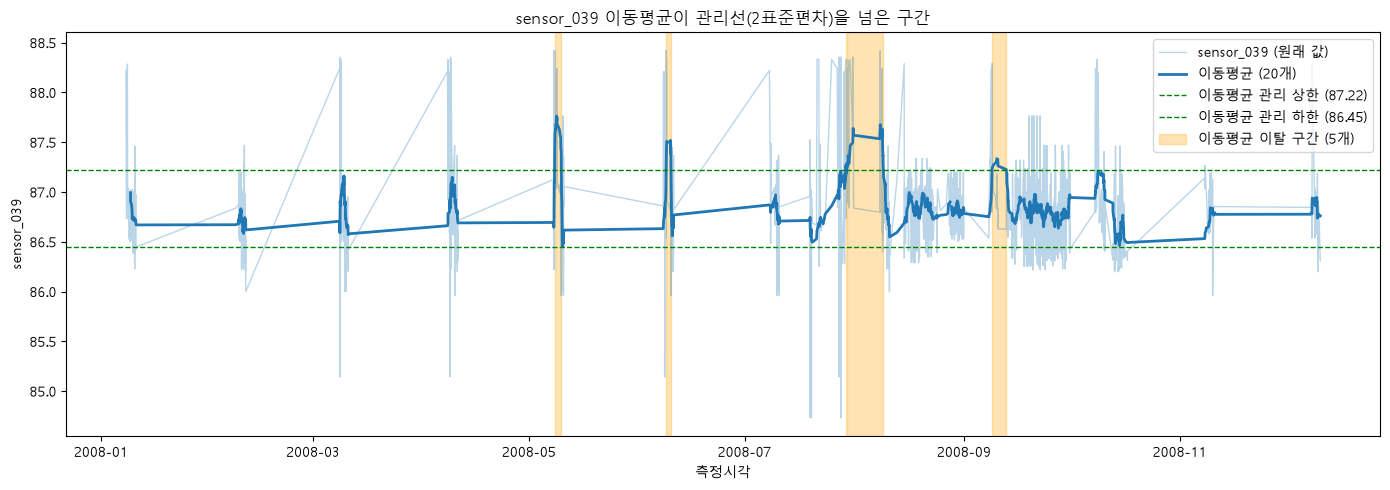

저장 완료: results/sensor_trend_zones.png


In [8]:
# 이동평균 자체의 평균 ± 2표준편차로 다시 관리선을 긋는다 (원래 값이 아니라 이동평균 기준)
이동평균_평균 = df["이동평균"].mean()
이동평균_표준편차 = df["이동평균"].std()
상한_이동 = 이동평균_평균 + 2 * 이동평균_표준편차
하한_이동 = 이동평균_평균 - 2 * 이동평균_표준편차

print(f"이동평균 평균 {이동평균_평균:.2f} / 표준편차 {이동평균_표준편차:.2f}")
print(f"관리 상한(2표준편차) {상한_이동:.2f} / 관리 하한(2표준편차) {하한_이동:.2f}")

이동평균_이탈 = (df["이동평균"] > 상한_이동) | (df["이동평균"] < 하한_이동)

# 연속으로 이어진 이탈만 하나의 구간으로 묶는다
그룹번호 = (이동평균_이탈 != 이동평균_이탈.shift()).cumsum()
이탈행 = df[이동평균_이탈].copy()
이탈행["_그룹"] = 그룹번호[이동평균_이탈]

구간목록 = []
for _, 부분 in 이탈행.groupby("_그룹"):
    구간목록.append({
        "시작시각": 부분["측정시각"].min(),
        "끝시각": 부분["측정시각"].max(),
        "건수": len(부분),
        "불량건수": int(부분["불량여부"].sum()),
        "불량률(%)": round(부분["불량여부"].mean() * 100, 2),
    })

구간표 = pd.DataFrame(구간목록)
print(f"\n넘은 구간 수: {len(구간표)}")
print(구간표.to_string(index=False))

# 그림에 원래 값·이동평균·관리선을 그리고, 이탈 구간을 색으로 표시한다
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df["측정시각"], df[센서], color="tab:blue", alpha=0.3, linewidth=1, label=f"{센서} (원래 값)")
ax.plot(df["측정시각"], df["이동평균"], color="tab:blue", linewidth=2, label="이동평균 (20개)")

ax.axhline(상한_이동, color="green", linestyle="--", linewidth=1, label=f"이동평균 관리 상한 ({상한_이동:.2f})")
ax.axhline(하한_이동, color="green", linestyle="--", linewidth=1, label=f"이동평균 관리 하한 ({하한_이동:.2f})")

for i, 행 in 구간표.iterrows():
    라벨 = f"이동평균 이탈 구간 ({len(구간표)}개)" if i == 0 else None
    ax.axvspan(행["시작시각"], 행["끝시각"], color="orange", alpha=0.3, label=라벨)

ax.set_xlabel("측정시각")
ax.set_ylabel(센서)
ax.set_title(f"{센서} 이동평균이 관리선(2표준편차)을 넘은 구간")
ax.legend(loc="upper right")
fig.tight_layout()

fig.savefig("results/sensor_trend_zones.png", dpi=150)
plt.show()

print("저장 완료: results/sensor_trend_zones.png")


### 흐름이 선을 넘은 구간

| 구간 | 언제부터 언제까지 | 그 구간 건수 | 불량 | 불량률 |
|---|---|---|---|---|
| 1 | [5월 8일 ~ 5월 10일] | [21] | [2] | [9.52%] |
| 2 | [6월 8일 ~ 6월 10일] | [15] | [2] | [13.33%] |
| 3 | [7월 29일 한 줄] | [1] | [1] | [100.00%] |
| 4 | [7월 29일 ~ 8월 9일] | [27] | [5] | [18.52%] |
| 5 | [9월 8일 ~ 9월 13일] | [13] | [2] | [15.38%] |

- 알게 된 것 : [구간 안 77건의 불량률이 15.58%로 전체 6.64%의 두 배 넘는다. 4번 구간이 가장 길고 불량도 가장 많다]
- 이게 한 줄씩 보는 것과 다른 점 : [언제부터 언제까지인지 기간이 나온다. 그 날짜에 무슨 일이 있었는지 물어볼 수 있다]
- 못 믿을 줄 : [3번 구간은 1건짜리라 100%가 아무 뜻이 없다]